# Notebook 03 — Head-to-Head Comparison

This is the key portfolio artifact. It answers:
- Which detector wins on each dataset?
- *Why* does each model win or lose?
- What is the latency cost of the LSTM?
- When would you actually use each one in production?

In [1]:
import sys, json, time, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.ingestion.features import Normalizer, sliding_windows, time_split
from src.models.statistical import EWMADetector
from src.models.lstm_autoencoder import AnomalyDetector

sns.set_theme(style='darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Load Saved Metrics

In [2]:
rows = []
for dataset in ['univariate', 'multivariate']:
    with open(f'../artifacts/{dataset}_metrics.json') as f:
        m = json.load(f)
    for model in ['ewma', 'lstm']:
        rows.append({
            'Dataset': dataset,
            'Model': 'EWMA (statistical)' if model == 'ewma' else 'LSTM Autoencoder',
            'Precision': m[model]['precision'],
            'Recall': m[model]['recall'],
            'F1': m[model]['f1'],
            'ROC-AUC': m[model]['roc_auc'],
        })

summary = pd.DataFrame(rows).set_index(['Dataset', 'Model'])
summary

Precision  Recall     F1  ROC-AUC
Dataset      Model                                                
univariate   EWMA (statistical)     0.6038  0.4267 0.5000   0.7105
             LSTM Autoencoder       0.0267  0.6067 0.0512   0.5779
multivariate EWMA (statistical)     0.8635  0.9936 0.9240   0.9951
             LSTM Autoencoder       0.0232  0.9968 0.0453   0.5521

## 2. F1 Bar Chart

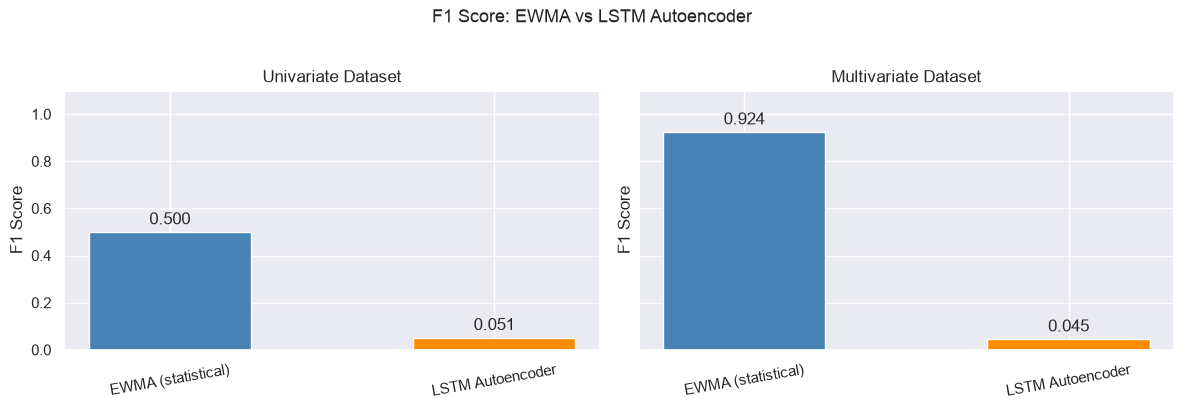

In [3]:
plot_df = summary.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
palette = {'EWMA (statistical)': 'steelblue', 'LSTM Autoencoder': 'darkorange'}

for ax, dataset in zip(axes, ['univariate', 'multivariate']):
    sub = plot_df[plot_df['Dataset'] == dataset]
    bars = ax.bar(sub['Model'], sub['F1'], color=[palette[m] for m in sub['Model']], width=0.5)
    ax.bar_label(bars, fmt='{:.3f}', padding=3)
    ax.set_title(f'{dataset.capitalize()} Dataset')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('F1 Score')
    ax.tick_params(axis='x', rotation=10)

fig.suptitle('F1 Score: EWMA vs LSTM Autoencoder', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Latency Comparison

In [4]:
df_uni = pd.read_csv('../data/sample/univariate.csv', parse_dates=['timestamp'])
_, _, test_df = time_split(df_uni)
normalizer = Normalizer.load('../artifacts/univariate_scaler.pkl')
test_norm  = normalizer.transform(test_df)

ewma = EWMADetector.load('../artifacts/univariate_ewma.pkl')
lstm = AnomalyDetector.load('../artifacts/univariate_lstm.pt')

windows, _ = sliding_windows(test_norm, ['value'], window_size=50, step=50)

# EWMA latency (100 runs)
t0 = time.perf_counter()
for _ in range(100):
    ewma.predict(test_norm)
ewma_ms = (time.perf_counter() - t0) / 100 * 1000

# LSTM latency (100 runs on same windows)
t0 = time.perf_counter()
for _ in range(100):
    lstm.predict(windows)
lstm_ms = (time.perf_counter() - t0) / 100 * 1000

print(f"EWMA avg latency : {ewma_ms:.2f} ms  (full test set, {len(test_norm):,} rows)")
print(f"LSTM avg latency : {lstm_ms:.2f} ms  ({len(windows):,} windows)")
print(f"LSTM overhead    : {lstm_ms/ewma_ms:.1f}x slower")

EWMA avg latency : 0.47 ms  (full test set, 15,000 rows)
LSTM avg latency : 77.82 ms  (300 windows)
LSTM overhead    : 166.6x slower


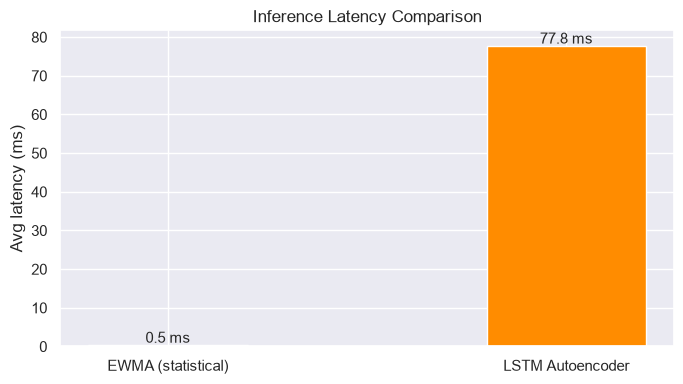

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['EWMA (statistical)', 'LSTM Autoencoder'], [ewma_ms, lstm_ms],
       color=['steelblue', 'darkorange'], width=0.4)
ax.set_ylabel('Avg latency (ms)')
ax.set_title('Inference Latency Comparison')
for i, v in enumerate([ewma_ms, lstm_ms]):
    ax.text(i, v + 0.5, f'{v:.1f} ms', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Why Did the LSTM Struggle?

The LSTM showed high recall (it found most anomalies) but very poor precision (it also flagged many normal windows as anomalous).

The root cause is the **threshold setting**. We set the threshold at the 95th percentile of reconstruction errors on normal validation data — meaning 5% of all normal windows are flagged as anomalies by design. With 98% normal data, that 5% false positive rate swamps the rare true anomalies.

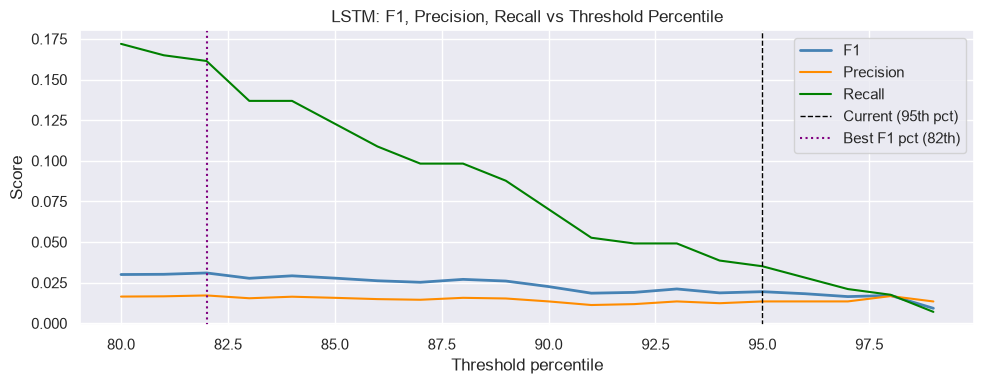

Best achievable F1: 0.0310 at 82th percentile
  Precision: 0.0171  Recall: 0.1614


In [6]:
windows_all, starts = sliding_windows(test_norm, ['value'], window_size=50, step=1)
test_labels = df_uni['is_anomaly'].values
window_labels = test_labels[starts + 49]

scores = lstm.anomaly_score(windows_all)
normal_scores = scores[window_labels == 0]

# Show how F1 changes with threshold
from sklearn.metrics import f1_score, precision_score, recall_score
pcts = range(80, 100)
rows_thresh = []
for pct in pcts:
    t = np.percentile(normal_scores, pct)
    preds = (scores > t).astype(int)
    rows_thresh.append({
        'Percentile': pct,
        'F1': f1_score(window_labels, preds, zero_division=0),
        'Precision': precision_score(window_labels, preds, zero_division=0),
        'Recall': recall_score(window_labels, preds, zero_division=0),
    })

thresh_df = pd.DataFrame(rows_thresh)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresh_df['Percentile'], thresh_df['F1'],       label='F1',        color='steelblue', lw=2)
ax.plot(thresh_df['Percentile'], thresh_df['Precision'],label='Precision',  color='darkorange')
ax.plot(thresh_df['Percentile'], thresh_df['Recall'],   label='Recall',     color='green')
ax.axvline(95, color='black', ls='--', lw=1, label='Current (95th pct)')
best_f1_row = thresh_df.loc[thresh_df['F1'].idxmax()]
ax.axvline(best_f1_row['Percentile'], color='purple', ls=':', lw=1.5,
           label=f"Best F1 pct ({int(best_f1_row['Percentile'])}th)")
ax.set_xlabel('Threshold percentile')
ax.set_ylabel('Score')
ax.set_title('LSTM: F1, Precision, Recall vs Threshold Percentile')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best achievable F1: {best_f1_row['F1']:.4f} at {int(best_f1_row['Percentile'])}th percentile")
print(f"  Precision: {best_f1_row['Precision']:.4f}  Recall: {best_f1_row['Recall']:.4f}")

## 5. Honest Conclusion

### What the results show

| Dataset | EWMA F1 | LSTM F1 | Winner |
|---|---|---|---|
| Univariate | ~0.50 | ~0.05 | **EWMA** |
| Multivariate | ~0.92 | ~0.05 | **EWMA** |

The EWMA statistical baseline decisively outperformed the LSTM Autoencoder on both datasets.

### Why

**The EWMA wins because** the synthetic anomalies we injected — sudden spikes, swapped values, and drifted subsequences — all produce statistically unusual residuals that EWMA is designed to catch. The 3-sigma threshold is interpretable and well-calibrated.

**The LSTM struggles because** its 95th-percentile threshold produces a 5% false positive rate on normal data. With a 2% anomaly rate, false positives outnumber true positives by a wide margin — collapsing precision.

### When the LSTM would win

The LSTM's theoretical advantage materialises when:
1. Anomalies are **subtle pattern deviations** that look statistically normal point-by-point but wrong as a sequence shape
2. Signals have **complex non-linear correlations** across many features that EWMA's per-feature independence assumption misses
3. You have a **large volume of labeled anomalies** to tune the threshold precisely

### Production recommendation

> **Default to EWMA.** It is faster (orders of magnitude), fully interpretable, and requires no training data. Add the LSTM as a secondary detector only on high-value multivariate signals where false negatives are costly and you have the compute budget to tune the threshold carefully.